In [2]:
# 重启后先运行这个 cell 重新加载环境模块
import importlib
import sys
if 'environment' in sys.modules:
    del sys.modules['environment']
import environment
from environment import WumpusWorldEnvironment
importlib.reload(environment)
from environment import WumpusWorldEnvironment

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# grid environment
from environment import WumpusWorldEnvironment

env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')

obs_sample, _ = env_grid.reset()

if isinstance(obs_sample, (int, np.integer)):
    grid_obs_dim = 1 
else:
    grid_obs_dim = len(obs_sample)

grid_action_dim = env_grid.action_space.n

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim) 
        )

    def forward(self, x):
        return self.fc(x)

In [5]:

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha  
        self.buffer = []
        self.pos = 0
        self.priorities = np.zeros((capacity,), dtype=np.float32)
    
    def push(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
        
        self.priorities[self.pos] = max_prio
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        """
        beta: 采样权重的修正系数 (随着训练增加，逐步从 0.4 增加到 1.0)
        """
        if len(self.buffer) == self.capacity:
            prios = self.priorities
        else:
            prios = self.priorities[:self.pos]
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()  # 归一化以保持训练稳定
        
        # 解压数据
        states, actions, rewards, next_states, dones = zip(*samples)
        
        return (np.array(states, dtype=np.float32), 
                np.array(actions, dtype=np.int64), 
                np.array(rewards, dtype=np.float32), 
                np.array(next_states, dtype=np.float32), 
                np.array(dones, dtype=np.float32), 
                indices, 
                np.array(weights, dtype=np.float32))

    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = prio + 1e-6

    def __len__(self):
        return len(self.buffer)

In [6]:

class PER_DQNAgent:
    def __init__(self, state_dim, action_dim, device="cpu"):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.device = device
        
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = PrioritizedReplayBuffer(capacity=10000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_decay = 0.996
        self.epsilon_min = 0.01
        self.beta = 0.4  
        self.beta_increment = 0.001

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.policy_net(state_t)
            return q_values.argmax().item()

    def update(self, batch_size):
        if len(self.memory) < batch_size:
            return None
        
        states, actions, rewards, next_states, dones, indices, weights = \
            self.memory.sample(batch_size, beta=self.beta)
        
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)
        weights = torch.FloatTensor(weights).to(self.device)

        current_q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q

        td_errors = torch.abs(target_q - current_q.squeeze()).detach()
        self.memory.update_priorities(indices, td_errors.cpu().numpy())

        loss = (weights * (current_q.squeeze() - target_q).pow(2)).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.beta = min(1.0, self.beta + self.beta_increment) # Beta 逐渐增加到 1.0
        
        return loss.item()

print("PER-DQN Agent is ready for training.")

PER-DQN Agent is ready for training.


In [7]:
#training loop
def train_per_dqn(env, agent, num_episodes, batch_size, target_update_freq):
    rewards_history = []
    losses_history = []
    
    for ep in range(num_episodes):
        state, _ = env.reset()
        ep_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            agent.memory.push(state, action, reward, next_state, done)
            
            loss = agent.update(batch_size)
            if loss:
                losses_history.append(loss)
                
            state = next_state
            ep_reward += reward
        
        if ep % target_update_freq == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())
            
        rewards_history.append(ep_reward)
        
        if ep % 20 == 0:
            print(f"Episode {ep} | Reward: {ep_reward:.1f} | Epsilon: {agent.epsilon:.2f} | Beta: {agent.beta:.2f}")
            
    return rewards_history, losses_history

In [8]:

env_grid = WumpusWorldEnvironment(observation_type='vector', action_type='discrete')
agent_grid = PER_DQNAgent(state_dim=2, action_dim=4, device=device)

print("Start training Grid-world...")
grid_rewards, grid_losses = train_per_dqn(env_grid, agent_grid, num_episodes=200, batch_size=32, target_update_freq=10)


Start training Grid-world...
Episode 0 | Reward: -103.0 | Epsilon: 1.00 | Beta: 0.40
Episode 20 | Reward: -214.0 | Epsilon: 0.12 | Beta: 0.93
Episode 40 | Reward: -101.0 | Epsilon: 0.06 | Beta: 1.00
Episode 60 | Reward: -101.0 | Epsilon: 0.05 | Beta: 1.00
Episode 80 | Reward: -101.0 | Epsilon: 0.04 | Beta: 1.00
Episode 100 | Reward: -101.0 | Epsilon: 0.02 | Beta: 1.00
Episode 120 | Reward: -101.0 | Epsilon: 0.02 | Beta: 1.00
Episode 140 | Reward: -101.0 | Epsilon: 0.02 | Beta: 1.00
Episode 160 | Reward: -101.0 | Epsilon: 0.01 | Beta: 1.00
Episode 180 | Reward: -101.0 | Epsilon: 0.01 | Beta: 1.00


In [9]:

env_cp = gym.make("CartPole-v1")

cp_state_dim = env_cp.observation_space.shape[0] 
cp_action_dim = env_cp.action_space.n        

print(f"CartPole 维度: State={cp_state_dim}, Action={cp_action_dim}")

agent_cp = PER_DQNAgent(state_dim=cp_state_dim, action_dim=cp_action_dim, device=device)

print("开始训练 CartPole-v1 (PER-DQN)...")
cp_rewards, cp_losses = train_per_dqn(
    env_cp, 
    agent_cp, 
    num_episodes=400, 
    batch_size=64,      
    target_update_freq=15 
)

env_cp.close()
print("CartPole 训练结束！")

CartPole 维度: State=4, Action=2
开始训练 CartPole-v1 (PER-DQN)...
Episode 0 | Reward: 20.0 | Epsilon: 1.00 | Beta: 0.40
Episode 20 | Reward: 19.0 | Epsilon: 0.33 | Beta: 0.68
Episode 40 | Reward: 15.0 | Epsilon: 0.10 | Beta: 0.97
Episode 60 | Reward: 37.0 | Epsilon: 0.01 | Beta: 1.00
Episode 80 | Reward: 122.0 | Epsilon: 0.01 | Beta: 1.00
Episode 100 | Reward: 187.0 | Epsilon: 0.01 | Beta: 1.00
Episode 120 | Reward: 16.0 | Epsilon: 0.01 | Beta: 1.00
Episode 140 | Reward: 170.0 | Epsilon: 0.01 | Beta: 1.00
Episode 160 | Reward: 143.0 | Epsilon: 0.01 | Beta: 1.00
Episode 180 | Reward: 115.0 | Epsilon: 0.01 | Beta: 1.00
Episode 200 | Reward: 134.0 | Epsilon: 0.01 | Beta: 1.00
Episode 220 | Reward: 110.0 | Epsilon: 0.01 | Beta: 1.00
Episode 240 | Reward: 121.0 | Epsilon: 0.01 | Beta: 1.00
Episode 260 | Reward: 130.0 | Epsilon: 0.01 | Beta: 1.00
Episode 280 | Reward: 144.0 | Epsilon: 0.01 | Beta: 1.00
Episode 300 | Reward: 240.0 | Epsilon: 0.01 | Beta: 1.00
Episode 320 | Reward: 116.0 | Epsilon:

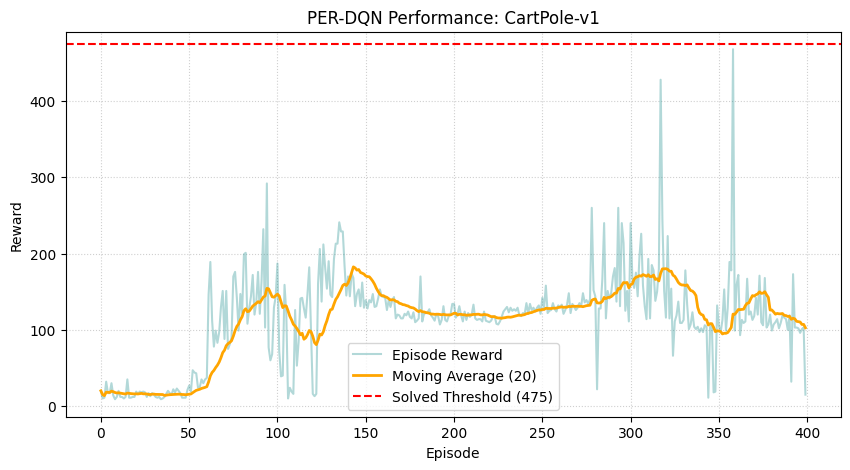

In [10]:
def plot_training_results(rewards, title):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, alpha=0.3, color='teal', label='Episode Reward')
    
    if len(rewards) > 20:
        ma_range = 20
        rolling_mean = [np.mean(rewards[max(0, i-ma_range):i+1]) for i in range(len(rewards))]
        plt.plot(rolling_mean, color='orange', linewidth=2, label='Moving Average (20)')
    
    plt.axhline(y=475, color='r', linestyle='--', label='Solved Threshold (475)')
    plt.title(f"PER-DQN Performance: {title}")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_training_results(cp_rewards, "CartPole-v1")

In [11]:

env_acro = gym.make("Acrobot-v1")

acro_s_dim = env_acro.observation_space.shape[0] 
acro_a_dim = env_acro.action_space.n 

print(f"Acrobot 维度: State={acro_s_dim}, Action={acro_a_dim}")

agent_acro = PER_DQNAgent(state_dim=acro_s_dim, action_dim=acro_a_dim, device=device)

print("开始训练 Acrobot-v1 (PER-DQN)...")

acro_rewards, acro_losses = train_per_dqn(
    env_acro, 
    agent_acro, 
    num_episodes=1000,  
    batch_size=128,    
    target_update_freq=20
)

env_acro.close()

Acrobot 维度: State=6, Action=3
开始训练 Acrobot-v1 (PER-DQN)...
Episode 0 | Reward: -500.0 | Epsilon: 0.22 | Beta: 0.77
Episode 20 | Reward: -500.0 | Epsilon: 0.01 | Beta: 1.00
Episode 40 | Reward: -500.0 | Epsilon: 0.01 | Beta: 1.00
Episode 60 | Reward: -500.0 | Epsilon: 0.01 | Beta: 1.00
Episode 80 | Reward: -484.0 | Epsilon: 0.01 | Beta: 1.00
Episode 100 | Reward: -364.0 | Epsilon: 0.01 | Beta: 1.00
Episode 120 | Reward: -362.0 | Epsilon: 0.01 | Beta: 1.00
Episode 140 | Reward: -183.0 | Epsilon: 0.01 | Beta: 1.00
Episode 160 | Reward: -500.0 | Epsilon: 0.01 | Beta: 1.00
Episode 180 | Reward: -390.0 | Epsilon: 0.01 | Beta: 1.00
Episode 200 | Reward: -348.0 | Epsilon: 0.01 | Beta: 1.00
Episode 220 | Reward: -500.0 | Epsilon: 0.01 | Beta: 1.00
Episode 240 | Reward: -108.0 | Epsilon: 0.01 | Beta: 1.00
Episode 260 | Reward: -172.0 | Epsilon: 0.01 | Beta: 1.00
Episode 280 | Reward: -229.0 | Epsilon: 0.01 | Beta: 1.00
Episode 300 | Reward: -174.0 | Epsilon: 0.01 | Beta: 1.00
Episode 320 | Rewar

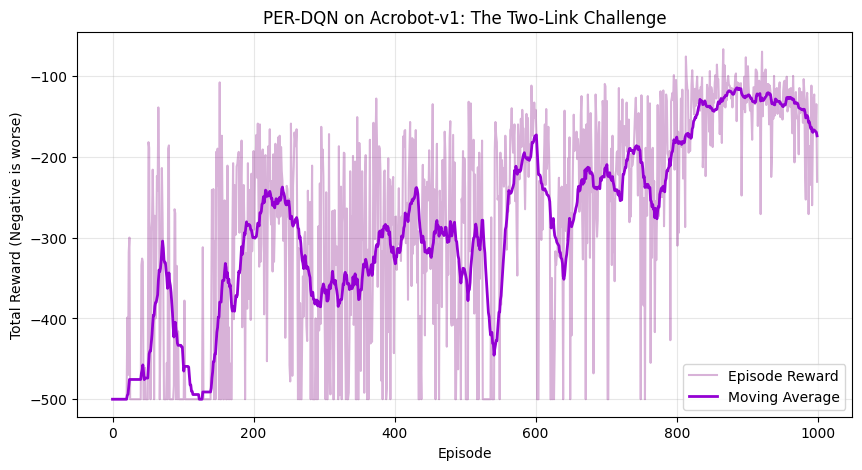

In [23]:
def plot_acrobot_results(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, color='purple', alpha=0.3, label='Episode Reward')
    
    ma_range = 20
    if len(rewards) > ma_range:
        smooth = [np.mean(rewards[max(0, i-ma_range):i+1]) for i in range(len(rewards))]
        plt.plot(smooth, color='darkviolet', linewidth=2, label='Moving Average')
    
    plt.title("PER-DQN on Acrobot-v1: The Two-Link Challenge")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward (Negative is worse)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_acrobot_results(acro_rewards)